In [1]:
# 1. Mount Google Drive to save results permanently
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone your GitHub repository
!git clone https://github.com/nativ670/consumer-satisfaction-network-analysis.git

# 3. Enter the project directory
%cd consumer-satisfaction-network-analysis

# 4. Install all required dependencies
!pip install -r requirements.txt
!pip install datasets

Mounted at /content/drive
Cloning into 'consumer-satisfaction-network-analysis'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 82 (delta 37), reused 71 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 306.44 KiB | 1.71 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/consumer-satisfaction-network-analysis
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all th

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Parsing reviews: 100%|██████████| 701528/701528 [31:57<00:00, 365.88it/s]


Batches:   0%|          | 0/26864 [00:00<?, ?it/s]

Sentiment Analysis: 100%|██████████| 690408/690408 [1:00:06<00:00, 191.42it/s]



Model           | Avg RMSE     | Avg Adj R2   | AIC          | BIC         
----------------------------------------------------------------------
Baseline        | 1.2144       | 0.3351       | 1039305.8    | 1039391.3   
Network         | 1.2012       | 0.3493       | 1032290.6    | 1032536.3   

BASELINE MODEL SUMMARY (Full Dataset):
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                 2.321e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        15:29:35   Log-Likelihood:            -5.1964e+05
No. Observations:              322133   AIC:                         1.039e+06
Df Residuals:                  322125   BIC:                         1.039e+06
Df Model:                   

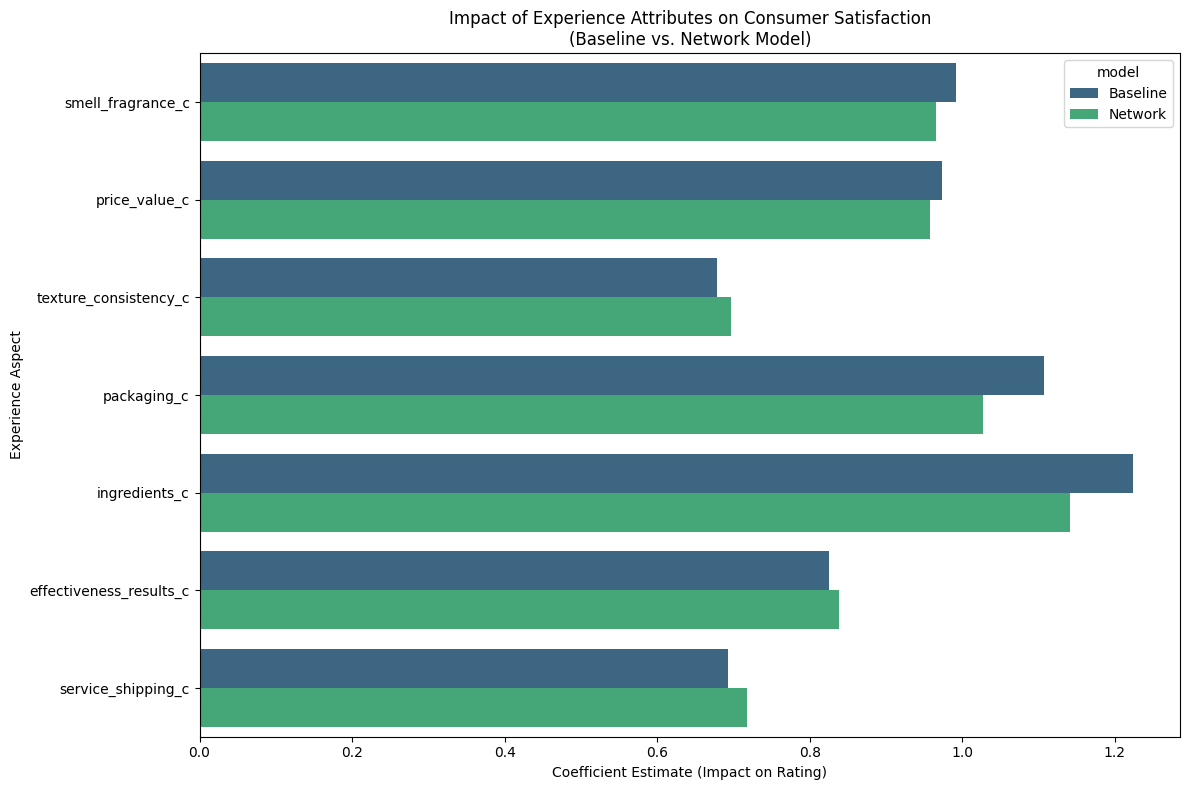

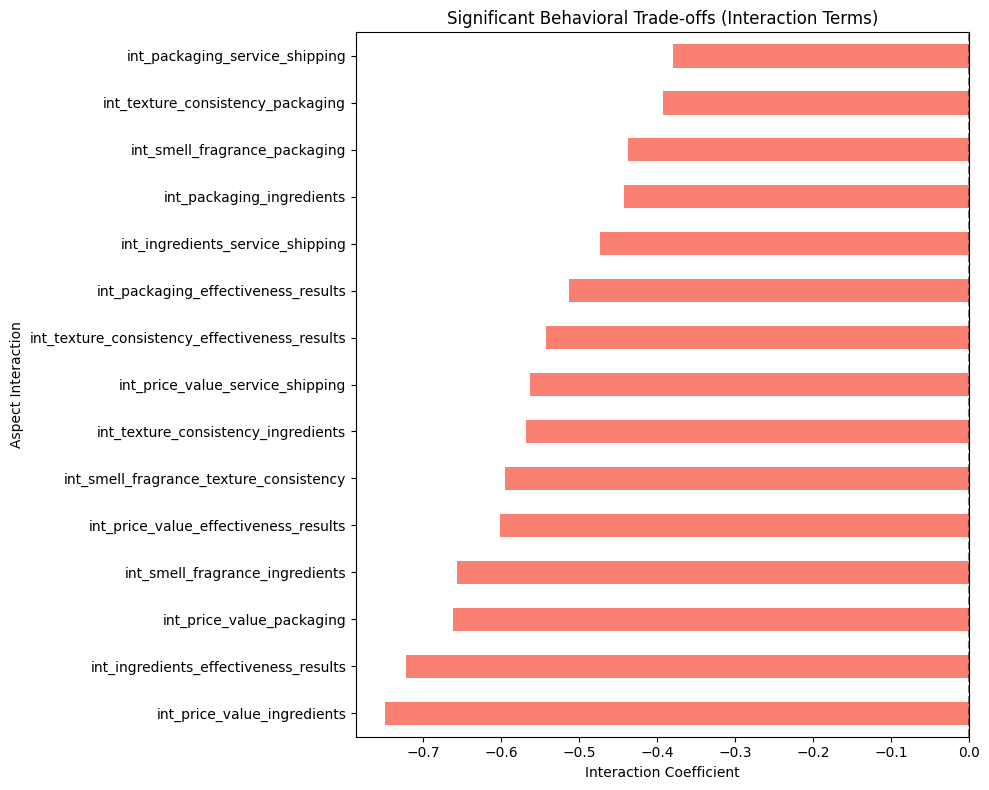

In [2]:
#@title Pipline Running & Analysis

import logging
import pandas as pd
from src.data_preprocessing import load_and_clean_data
from src.nlp_extraction import extract_aspects_and_sentiments
from src.network_builder import build_and_analyze_network
from src.modeling import compare_models

# defining the logs
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# full saved data
SAVE_PATH = '/content/drive/MyDrive/Seminar_Amazon_Results_FULL.csv'

try:
    # loading the full dataset
    logger.info("Loading FULL Beauty dataset...")
    df = load_and_clean_data()
    logger.info(f"Loaded {len(df)} total reviews.")

    # NLP running
    logger.info("Starting Batched NLP Extraction on GPU for the full dataset...")
    processed_df = extract_aspects_and_sentiments(df)

    # saving to drive
    processed_df.to_csv(SAVE_PATH, index=False)
    logger.info(f"✅ SUCCESS: Full NLP results safely backed up to: {SAVE_PATH}")

    # building the full network
    logger.info("Building the cognitive network...")
    network_results = build_and_analyze_network(processed_df)
    G = network_results['graph']

    # final statistical models
    logger.info("Running Statistical Evaluation on full data...")
    models = compare_models(processed_df, G)
    baseline_model = models['baseline']
    final_model = models['network']

    # Evaluation and Visualizations
    from src.evaluation import plot_coefficient_comparison, plot_interaction_heatmap, run_likelihood_ratio_test

    logger.info("Running detailed model evaluation...")
    run_likelihood_ratio_test(models)
    plot_coefficient_comparison(models)
    plot_interaction_heatmap(models['network'])

except Exception as e:
    logger.error(f"Something went wrong: {e}")
    import traceback
    traceback.print_exc()

In [3]:
#@title Network Analysis
import pandas as pd
import networkx as nx
import os
import ast
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your processed data
PROCESSED_DATA_PATH = '/content/drive/MyDrive/Seminar_Amazon_Results_FULL.csv'

if not os.path.exists(PROCESSED_DATA_PATH):
  print(f"❌ Error: File not found at {PROCESSED_DATA_PATH}")
else:
  # 3. Load the data
  print(f"📂 Loading processed data from {PROCESSED_DATA_PATH}...")
  df = pd.read_csv(PROCESSED_DATA_PATH)

  # 4. Fix for CSV string serialization (Patching the DataFrame)
  print("🛠️  Parsing aspect_sentiments strings into Python objects...")
  def safe_parse(val):
      if isinstance(val, str) and val.startswith('['):
          try:
              return ast.literal_eval(val)
          except:
              return []
      return val

  df['aspect_sentiments'] = df['aspect_sentiments'].apply(safe_parse)

  # 5. Import and Run Analysis
  from src.network_builder import build_and_analyze_network

  print("🕸️  Constructing cognitive network and calculating metrics...")
  results = build_and_analyze_network(df)
  G = results['graph']
  metrics = results['metrics']
  sorted_edges = results['sorted_edges']

  # 6. Print Results
  print("\n" + "="*80)
  print("CONSUMER BEHAVIOR NETWORK METRICS (PageRank, Centrality, Tie Strength)")
  print("="*80)

  print(f"\n{'Core Aspect':<30} | {'PageRank':<12} | {'Degree Cent.':<12}")
  print("-" * 80)

  sorted_nodes = sorted(G.nodes(), key=lambda x: metrics['eigenvector'].get(x, 0), reverse=True)
  for aspect in sorted_nodes:
      pagerank = metrics['eigenvector'].get(aspect, 0)
      degree = metrics['degree'].get(aspect, 0)
      print(f"{aspect:<30} | {pagerank:<12.4f} | {degree:<12.4f}")

  print("\n" + "="*80)
  print("TOP TIE STRENGTHS (Partial Correlations)")
  print("="*80)
  print(f"{'Interaction (Edge)':<45} | {'Tie Strength':<15}")
  print("-" * 80)

  for u, v, weight in sorted_edges[:10]:
      print(f"{f'{u} <-> {v}':<45} | {weight:<15.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading processed data from /content/drive/MyDrive/Seminar_Amazon_Results_FULL.csv...
🛠️  Parsing aspect_sentiments strings into Python objects...
🕸️  Constructing cognitive network and calculating metrics...

CONSUMER BEHAVIOR NETWORK METRICS (PageRank, Centrality, Tie Strength)

Core Aspect                    | PageRank     | Degree Cent.
--------------------------------------------------------------------------------
ingredients                    | 0.2434       | 0.3481      
packaging                      | 0.2027       | 0.2889      
price/value                    | 0.1363       | 0.1870      
service/shipping               | 0.1095       | 0.1459      
smell/fragrance                | 0.1092       | 0.1423      
effectiveness/results          | 0.1021       | 0.1314      
texture/consistency            | 0.0969       | 0.1210      

TOP TIE STRENGTHS

## Part 3: Statistical Modeling and Evaluation
This section replicates the modeling logic and formatting from notebooks 02 and 03, incorporating the 'Kitchen Sink' model and scientific comparison metrics.

\n==================================================
SCIENTIFIC MODEL COMPARISON
\nBASELINE:
R2: 0.3353 | Adj R2: 0.3353 | BIC: 1039391.31
Coefficients:
Intercept                3.940040
ingredients              1.224358
packaging                1.107022
smell_fragrance          0.991980
price_value              0.973841
effectiveness_results    0.824851
service_shipping         0.693342
texture_consistency      0.679003
dtype: float64
\nGLASSO NETWORK:
R2: 0.3497 | Adj R2: 0.3496 | BIC: 1032536.33
Coefficients:
Intercept                                    3.968649
ingredients                                  1.140966
packaging                                    1.027000
smell_fragrance                              0.965452
price_value                                  0.958279
effectiveness_results                        0.838350
service_shipping                             0.717422
texture_consistency                          0.696430
packaging:service_shipping                  -0.379

/tmp/ipykernel_2165/4076874497.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='BIC', data=results_df, palette='magma')


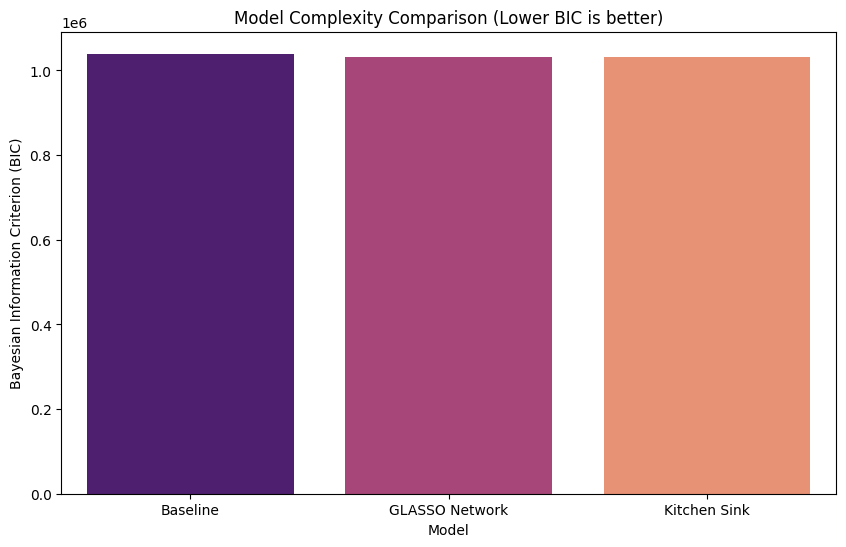

/tmp/ipykernel_2165/4076874497.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y=main_effects.index, data=main_effects, palette='viridis', ax=axes[0])
/tmp/ipykernel_2165/4076874497.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y=interactions.index, data=interactions, palette='coolwarm', ax=axes[1])


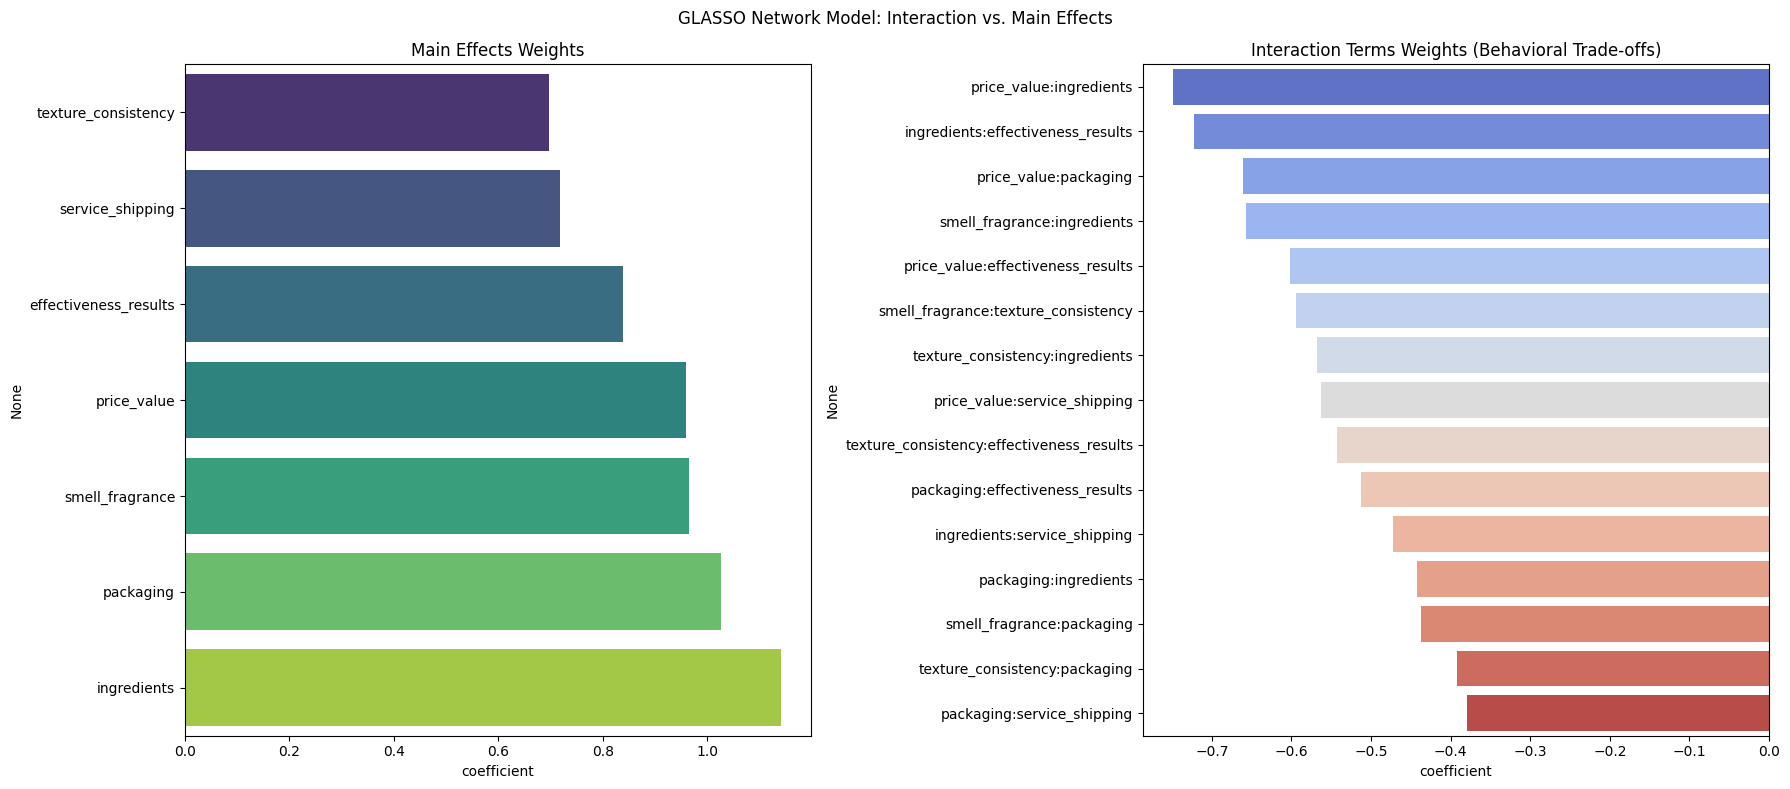

In [4]:
# 1. Define Modeling Data & Mapping
CORE_ASPECTS = [
    'ingredients', 'packaging', 'price/value', 'service/shipping',
    'smell/fragrance', 'effectiveness/results', 'texture/consistency'
]

NAME_MAP = {
    'ingredients': 'ingredients',
    'packaging': 'packaging',
    'price/value': 'price_value',
    'service/shipping': 'service_shipping',
    'smell/fragrance': 'smell_fragrance',
    'effectiveness/results': 'effectiveness_results',
    'texture/consistency': 'texture_consistency'
}

# Use the edges found in the network analysis
GLASSO_EDGES = [(u, v) for u, v, w in sorted_edges]

# Prepare data for smf.ols (Formula API)
import statsmodels.formula.api as smf
import ast

def process_for_modeling(df):
    # Pivot and average
    exploded = df[['aspect_sentiments']].explode('aspect_sentiments')
    exploded = exploded.dropna(subset=['aspect_sentiments'])
    aspect_sent = pd.DataFrame(exploded['aspect_sentiments'].tolist(), index=exploded.index)
    aspect_sent.columns = ['aspect', 'sentiment']
    pivoted = aspect_sent.groupby([aspect_sent.index, 'aspect'])['sentiment'].mean().unstack(fill_value=0.0)

    # Rename and ensure columns
    final_aspects = []
    for raw_name in CORE_ASPECTS:
        clean_name = NAME_MAP.get(raw_name, raw_name.replace('/', '_').replace(' ', '_'))
        if raw_name in pivoted.columns:
            pivoted = pivoted.rename(columns={raw_name: clean_name})
        else:
            if clean_name not in pivoted.columns:
                pivoted[clean_name] = 0.0
        final_aspects.append(clean_name)

    data = pivoted.join(df[['rating']])
    data = data.dropna(subset=['rating'])
    data = data[(data[final_aspects] != 0).any(axis=1)].copy()

    # Mean-centering
    for col in final_aspects:
        data[col] = data[col] - data[col].mean()

    return data, final_aspects

model_data, base_features = process_for_modeling(df)

# 2. Define Formulas
baseline_formula = "rating ~ " + " + ".join(base_features)

glasso_interactions = [f"{NAME_MAP.get(u, u.replace('/', '_').replace(' ', '_'))} * {NAME_MAP.get(v, v.replace('/', '_').replace(' ', '_'))}" for u, v in GLASSO_EDGES]
glasso_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(glasso_interactions)

all_interactions = []
for i in range(len(base_features)):
    for j in range(i + 1, len(base_features)):
        all_interactions.append(f"{base_features[i]} * {base_features[j]}")
kitchen_sink_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(all_interactions)

# 3. Fit Models
model_baseline = smf.ols(baseline_formula, data=model_data).fit()
model_glasso = smf.ols(glasso_formula, data=model_data).fit()
model_kitchen = smf.ols(kitchen_sink_formula, data=model_data).fit()

# 4. Scientific Comparison (PRINTING IN SAME FORMAT AS 02/03)
print("\\n" + "="*50)
print("SCIENTIFIC MODEL COMPARISON")
print("="*50)
models = [('Baseline', model_baseline), ('GLASSO Network', model_glasso), ('Kitchen Sink', model_kitchen)]
results = []
for name, model in models:
    results.append({
        'Model': name,
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'BIC': model.bic,
        'Params': len(model.params)
    })
    print(f"\\n{name.upper()}:")
    print(f"R2: {model.rsquared:.4f} | Adj R2: {model.rsquared_adj:.4f} | BIC: {model.bic:.2f}")
    print("Coefficients:")
    print(model.params[model.params != 0].sort_values(ascending=False))

# 5. Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='BIC', data=results_df, palette='magma')
plt.title('Model Complexity Comparison (Lower BIC is better)')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.show()

# Coefficients Plot for GLASSO Model
coef_df = model_glasso.params.drop('Intercept')
interactions = coef_df[coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')
main_effects = coef_df[~coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Main Effects
if not main_effects.empty:
    sns.barplot(x='coefficient', y=main_effects.index, data=main_effects, palette='viridis', ax=axes[0])
axes[0].set_title('Main Effects Weights')

# Interaction Terms
if not interactions.empty:
    sns.barplot(x='coefficient', y=interactions.index, data=interactions, palette='coolwarm', ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'No Interaction Terms Found', ha='center', va='center')
axes[1].set_title('Interaction Terms Weights (Behavioral Trade-offs)')

plt.suptitle('GLASSO Network Model: Interaction vs. Main Effects')
plt.tight_layout()
plt.show()